In [34]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [35]:
X = np.load("lowresolution.npy")    # (320, 6, 160, 160)
y = np.load("highresolution.npy")   # (320, 160, 160)


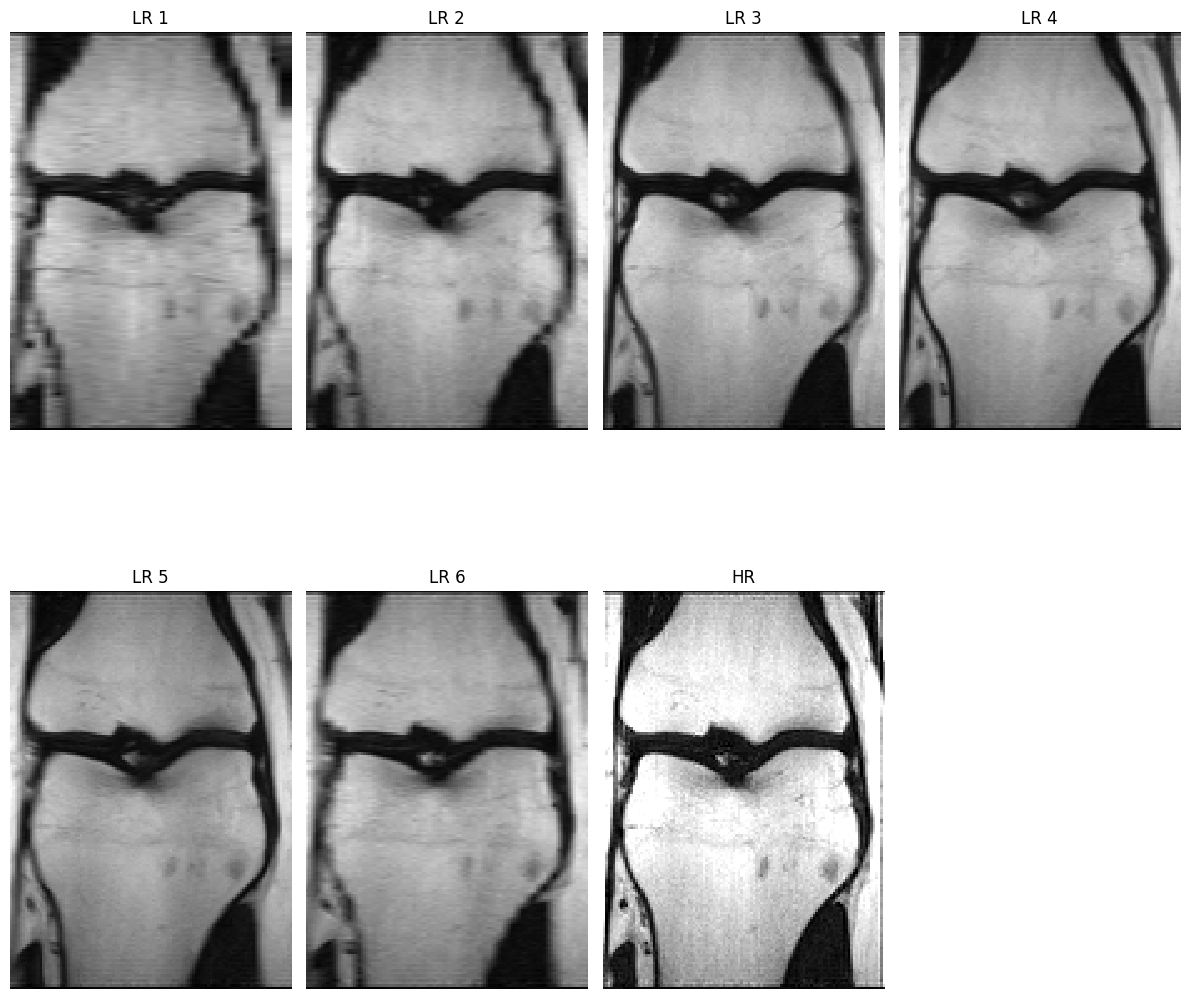

In [36]:

idx = 226 
plt.figure(figsize=(12, 12)) 
for i in range(6): 
    plt.subplot(2, 4, i + 1) 
    plt.imshow(X[idx,:,:, i], cmap='gray',interpolation='none') 
    plt.title(f'LR {i+1}') 
    plt.axis('off') 
plt.subplot(2, 4, 7) 
plt.imshow(y[idx], cmap='gray', vmin=0, vmax=10000,interpolation='none') 
plt.title('HR') 
plt.axis('off') 
plt.tight_layout() 
plt.show()


In [37]:
X = X.astype(np.float32)
y = y.astype(np.float32)

X = (X - X.min()) / (X.max() - X.min())
y = (y - y.min()) / (y.max() - y.min())

# Dodanie kanału do y
y = y[:, None, :, :]  # (320, 1, 160, 160)

In [38]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [39]:
BATCH_SIZE = 16
EPOCHS = 20
LR = 1e-3
DEVICE = "cpu"
class MRIDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]           # [H, W, 6]
        y = self.y[idx]           # [H, W]
        x = x.permute(2, 0, 1)    # → [6, H, W]
        return x, y

train_loader = DataLoader(
    MRIDataset(X_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    MRIDataset(X_val, y_val),
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Model CNN

class MultiViewCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            # Blok 1: Wstępne przetwarzanie
            nn.Conv2d(6, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            
            # Blok 2: Zwiększenie liczby filtrów
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            
            # Blok 3: Większy kernel size dla większego receptive field
            nn.Conv2d(128, 256, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv2d(256, 128, kernel_size=5, padding=2),
            nn.ReLU(),
            
            # Blok 4: Zmniejszanie dimensji i wzmacnianie cech
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            
            # Wyjście
            nn.Conv2d(64, 1, kernel_size=3, padding=1)
        )

    def forward(self, x):
        return self.net(x)

model = MultiViewCNN().to(DEVICE)

# Loss + optimizer

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)


cgun

collab

nauczyć aby dodać krawędzie dużej rodzielczości


In [40]:
X_batch, _ = next(iter(train_loader))
print(X_batch.shape)


torch.Size([16, 6, 160, 113])


Epoch 1/20 | Train loss: 0.312236 | Val loss: 0.219110
Epoch 2/20 | Train loss: 0.080497 | Val loss: 0.011514
Epoch 3/20 | Train loss: 0.007093 | Val loss: 0.005089
Epoch 4/20 | Train loss: 0.004387 | Val loss: 0.004161
Epoch 5/20 | Train loss: 0.003999 | Val loss: 0.003910
Epoch 6/20 | Train loss: 0.003613 | Val loss: 0.003560
Epoch 7/20 | Train loss: 0.003175 | Val loss: 0.002867
Epoch 8/20 | Train loss: 0.002441 | Val loss: 0.002037
Epoch 9/20 | Train loss: 0.001541 | Val loss: 0.001108
Epoch 10/20 | Train loss: 0.000992 | Val loss: 0.001039
Epoch 11/20 | Train loss: 0.000794 | Val loss: 0.000618
Epoch 12/20 | Train loss: 0.000565 | Val loss: 0.000510
Epoch 13/20 | Train loss: 0.000502 | Val loss: 0.000512
Epoch 14/20 | Train loss: 0.000450 | Val loss: 0.000533
Epoch 15/20 | Train loss: 0.000451 | Val loss: 0.000489
Epoch 16/20 | Train loss: 0.000412 | Val loss: 0.000416
Epoch 17/20 | Train loss: 0.000408 | Val loss: 0.000389
Epoch 18/20 | Train loss: 0.000419 | Val loss: 0.000403
E

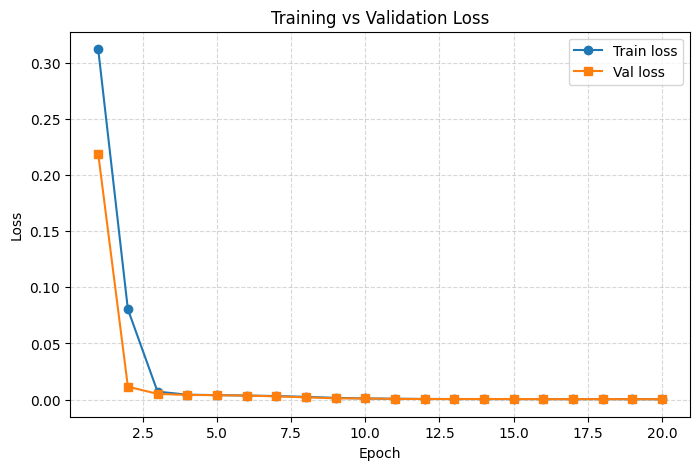

In [41]:
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.float().to(DEVICE)
        y_batch = y_batch.float().to(DEVICE)

        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # Walidacja
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train loss: {train_loss:.6f} | "
        f"Val loss: {val_loss:.6f}"
    )

# --- Generowanie wykresu po zakończeniu treningu ---
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, EPOCHS+1), train_losses, 'o-', label="Train loss")
plt.plot(range(1, EPOCHS+1), val_losses, 's-', label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()


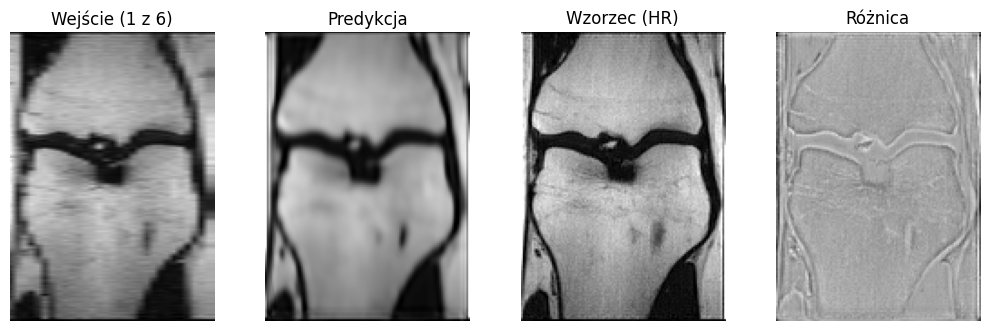

In [43]:
model.eval() 
with torch.no_grad(): 
    X_example, y_example = next(iter(val_loader)) 
    X_example = X_example.to(DEVICE) 
    y_pred = model(X_example).cpu().numpy()
sample_idx = 1

X_np = X_example[sample_idx, 0].cpu().numpy()
y_pred_np = y_pred[sample_idx, 0]
y_true_np = y_example[sample_idx, 0].cpu().numpy()

plt.figure(figsize=(10, 4))

plt.subplot(1, 4, 1)
plt.title("Wejście (1 z 6)")
plt.imshow(X_np, cmap="gray")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.title("Predykcja")
plt.imshow(y_pred_np, cmap="gray",
           vmin=np.min(y_true_np), vmax=np.max(y_true_np)*0.75, interpolation=None)
plt.axis("off")

plt.subplot(1, 4, 3)
plt.title("Wzorzec (HR)")
plt.imshow(y_true_np, cmap="gray",
           vmin=np.min(y_true_np), vmax=np.max(y_true_np)*0.75, interpolation=None)
plt.axis("off")

plt.subplot(1,4,4)
plt.title("Różnica")
plt.imshow((y_pred_np - y_true_np), cmap="gray", interpolation=None)
plt.tight_layout()
plt.axis("off")
plt.show()
